In [2]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [3]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 400
WINDOW_STRIDE_SAMPLES = 25
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians

In [4]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        rtParent.title AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
),

no_gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        'No Gesture' AS gesture,
        'No Gesture' AS parent_gesture,
        s.participant_id,
        0 AS is_gesture,
        NULL  AS group_id
    FROM sensorData sd
    LEFT JOIN gesture_samples gs 
      ON gs.id = sd.id -- Check if this row was already labeled as a gesture
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    
    -- Exclude rows that were found in gesture_samples (gs.id IS NULL)
    -- Also keep your original session_task_id and 'Szenarien' filters
    WHERE gs.id IS NULL
      AND sd.session_task_id IN (
          SELECT DISTINCT session_task_id FROM preciseMarker
      )
      AND rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
-- UNION ALL
-- SELECT * FROM no_gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [5]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [6]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [7]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        25966
Tap and Hold                      11985
Pinch Swipe                       11370
Spread Swipe                       9049
Single Swipe                       6072
Two-Finger Opposite Double Tap     2929
Two-Finger Double Tap              2859
Double Tap                         2762
Two-Finger Opposite Tap            1719
Two-Finger Tap                     1610
Single Tap                         1377
Name: count, dtype: int64

In [8]:
# Remove all No Gesture rows
df_raw = df_raw[df_raw[LABEL_COLUMN] != 'No Gesture'].reset_index(drop=True)

In [9]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [10]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    5774
6331fbd1-76bb-48d6-92a2-80a55a70d134    6338
696b4743-9d39-4fb1-8271-90e7d48652af    5229
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    7299
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    7472
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    5821
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    7347
fdd02af8-c764-43ba-8247-c612f85568b4    6452
dtype: int64

In [11]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel']

In [12]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [13]:
# Stabilize dataset
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())

# # Final step: Replace the old columns in your original DataFrame
# # 1. Get non-touch columns from the original df
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

# # 2. Join the non-touch columns with the new stabilized touch data
df_clean = final_df.join(stabilized_touch_data)
print("Stabilization Complete.")

Stabilization Complete.


In [14]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(2, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position    15127
touch_1_pressure    15127
touch_1_channel     15127
touch_2_position        0
touch_2_pressure        0
touch_2_channel         0
touch_3_position        0
touch_3_pressure        0
touch_3_channel         0
touch_4_position        0
touch_4_pressure        0
touch_4_channel         0
touch_5_position        0
touch_5_pressure        0
touch_5_channel         0
dtype: int64

In [15]:
# Print the min, max and mean count of samples per group_id
grouped = df_clean.groupby('group_id').size()
print(f"Min samples per group_id: {grouped.min()}")
print(f"Max samples per group_id: {grouped.max()}")
print(f"Mean samples per group_id: {grouped.mean():.2f}")

# Print the parent_gesture for the group_id with the maximum samples
max_group_id = grouped.idxmax()
max_parent_gesture = df_clean[df_clean['group_id'] == max_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with max samples ({max_group_id}): {max_parent_gesture}")

# Print the parent_gesture for the group_id with the minimum samples
min_group_id = grouped.idxmin()
min_parent_gesture = df_clean[df_clean['group_id'] == min_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with min samples ({min_group_id}): {min_parent_gesture}")

# Print the count of samples for the No Gesture parent_gesture that has the max samples
no_gesture_grouped = df_clean[df_clean['parent_gesture'] == 'No Gesture'].groupby('group_id').size()
print(f"Max samples for 'No Gesture' group_id: {no_gesture_grouped.max()}")

Min samples per group_id: 8
Max samples per group_id: 406
Mean samples per group_id: 52.90
Parent gesture for group_id with max samples (2026-01-06 14:41:54): Tap and Hold
Parent gesture for group_id with min samples (2025-12-29 10:09:06): Two-Finger Tap
Max samples for 'No Gesture' group_id: nan


In [16]:
# The window size for windows that contain a full gesture
FULL_GESTURE_WINDOW_SIZE = grouped.max()

def pad_pre(sequence_2d, target_len):
    T, F = sequence_2d.shape
    if T == target_len:
        return sequence_2d

    if T > target_len:
        # truncate: keep last target_len steps (end of gesture)
        return sequence_2d[-target_len:, :]

    # T < target_len: pre-pad with zeros at the start
    pad_len = target_len - T
    pad_block = np.zeros((pad_len, F), dtype=sequence_2d.dtype)
    return np.vstack([pad_block, sequence_2d])


In [17]:
X_sequences_raw = []
y_labels = []
meta = []   # optional: to keep ids for later analysis

for gesture_id, g in df_clean.groupby("group_id"):
    # extract raw sequence for this gesture
    seq = g[SENSOR_COLUMNS].to_numpy()   # shape (T, F)
    # Add the original sequence length as a feature
    original_length = seq.shape[0]
    padded = pad_pre(seq, FULL_GESTURE_WINDOW_SIZE)  # shape (FULL_GESTURE_WINDOW_SIZE, F)
    # Add the original length as the last feature
    padded = np.hstack([padded, np.full((FULL_GESTURE_WINDOW_SIZE, 1), original_length)])

    # Print if the padded seq contains nan
    if np.isnan(padded).any():
        print(f"Warning: NaN values found in padded sequence for gesture_id {gesture_id}")

    X_sequences_raw.append(padded)
    y_labels.append(g[LABEL_COLUMN].iloc[0])  # same label for whole gesture

    meta.append({
        "group_id": gesture_id,
        "participant_id": g["participant_id"].iloc[0],
        "session_task_id": g["session_task_id"].iloc[0],
    })

X_sequences_raw = np.stack(X_sequences_raw, axis=0)  # shape (N_gestures, FULL_GESTURE_WINDOW_SIZE, F)
y_labels = np.array(y_labels)
meta = pd.DataFrame(meta)


In [18]:
# Print distinct labels
distinct_labels = np.unique(y_labels)
print(f"Distinct labels: {distinct_labels}")
# Print min and max length of sequences after padding to check it worked
sequence_lengths = [seq.shape[0] for seq in X_sequences_raw]
print(f"Min sequence length after padding: {min(sequence_lengths)}")
print(f"Max sequence length after padding: {max(sequence_lengths)}")
# Print amount of windows
print(f"Total number of windows: {len(X_sequences_raw)}")

Distinct labels: ['Double Tap' 'Pinch Swipe' 'Single Swipe' 'Single Tap' 'Spread Swipe'
 'Tap and Hold' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Min sequence length after padding: 406
Max sequence length after padding: 406
Total number of windows: 978


In [19]:
def extract_features(window, is_padded_window):
    features = []
    feature_names = [] # for debug purposes we store the names of each feature at the same index
    
    # Assume sensor column order from SENSOR_COLUMNS
    # Indices: button=0, motor=1, touch_pos=[2,5,8,11,14], touch_press=[3,6,9,12,15]
    button_col = 0
    motor_col = 1
    touch_channel_cols = [4, 7, 10, 13, 16]  # touch_X_channel indices
    touch_pressure_cols = [3, 6, 9, 12, 15]  # touch_X_pressure indices
    touch_position_cols = [2, 5, 8, 11, 14]  # touch_X_position indices
    original_length_col = len(SENSOR_COLUMNS)  # last column is original length

    button_press_data = window[:, button_col]
    motor_data = window[:, motor_col]
    touch_pressures = window[:, touch_pressure_cols]
    touch_positions = window[:, touch_position_cols]
    # Only consider touch positions where the pressure > 0
    valid_mask = touch_pressures > 0
    touch_positions = touch_positions[valid_mask]
    original_length = int(window[0, original_length_col]) if is_padded_window else window.shape[0]

    # A 1 signalizes the button was pressed, this can happen multiple times in a window, so we first have to extract each consecutive time a button was pressed, plus the amount of samples for each time
    binary_button_press = (button_press_data > 0).astype(int)
    padded_button_press = np.concatenate(([0], binary_button_press, [0]))
    button_press_diff = np.diff(padded_button_press)
    button_press_starts = np.where(button_press_diff == 1)[0]
    button_press_ends = np.where(button_press_diff == -1)[0]
    button_press_durations = button_press_ends - button_press_starts

    def circular_range(angles):
        # 1. Sort the angles
        sorted_angles = np.sort(angles)
        # 2. Calculate gaps between neighbors
        gaps = np.diff(sorted_angles)
        # 3. Calculate the wrap-around gap (last to first)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        # 4. Combine all gaps
        all_gaps = np.append(gaps, wrap_gap)
        # 5. Range is the full circle minus the biggest empty space
        return 2 * np.pi - np.max(all_gaps)
    
    def add_feature(name, value):
        features.append(value)
        feature_names.append(name)

    # Button Features
    # 1. Button pressed at all?
    add_feature("button_pressed_any", np.any(binary_button_press))
    # # 2. How often was the button pressed (changed from 0 to 1 and vice versa) and how often was it let go
    add_feature("button_press_count", len(button_press_starts))
    # # 3. Mean (raw + durations)
    add_feature("button_press_mean", np.mean(binary_button_press))
    add_feature("button_press_duration_mean", np.mean(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 4. Std Dev (raw + durations)
    add_feature("button_press_std", np.std(binary_button_press))
    add_feature("button_press_duration_std", np.std(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 5. Median (raw + durations)
    add_feature("button_press_median", np.median(binary_button_press))
    add_feature("button_press_duration_median", np.median(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 6. Max duration
    add_feature("button_press_max_duration", np.max(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 7. Min duration
    add_feature("button_press_min_duration", np.min(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 8. Range duration
    add_feature("button_press_range_duration", circular_range(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 9. Total duration
    add_feature("button_press_total_duration", np.sum(button_press_durations) if len(button_press_durations) > 0 else 0)

    # Motor Angle Features
    # 1. Mean
    add_feature("motor_angle_mean", np.mean(motor_data))
    # # 2. Std Dev
    add_feature("motor_angle_std", np.std(motor_data))
    # # 3. Min Max
    add_feature("motor_angle_min", np.min(motor_data))
    add_feature("motor_angle_max", np.max(motor_data))
    # # 4. Range
    add_feature("motor_angle_range", circular_range(motor_data))
    # # 5. Median
    add_feature("motor_angle_median", np.median(motor_data))
    # # 6. Q25 / Q75
    add_feature("motor_angle_q25", np.percentile(motor_data, 25))
    add_feature("motor_angle_q75", np.percentile(motor_data, 75))
    # # 7. Skewness / Kurtosis
    add_feature("motor_angle_skewness", stats.skew(motor_data))
    add_feature("motor_angle_kurtosis", stats.kurtosis(motor_data))
    # # 8. Velocity
    if len(motor_data) > 1:
        motor_velocity = np.diff(motor_data) * SAMPLING_RATE_HZ
        add_feature("motor_velocity_mean", np.mean(motor_velocity))
        add_feature("motor_velocity_std", np.std(motor_velocity))
        add_feature("motor_velocity_max", np.max(motor_velocity))
    else:
        add_feature("motor_velocity_mean", 0)
        add_feature("motor_velocity_std", 0)
        add_feature("motor_velocity_max", 0)

    # General Touch Activity Features
    # 1. Max simultaneous touches
    active_touches = (touch_pressures > 0).astype(int)
    add_feature("max_simultaneous_touches", np.max(np.sum(active_touches, axis=1)))
    # 2. Avg active touches
    add_feature("avg_active_touches", np.mean(np.sum(active_touches, axis=1)))
    # 3. Any touch at all?
    add_feature("any_touch", np.any(active_touches))
    # 4. Total pressure across all sensors
    add_feature("total_active_touch_samples", np.sum(active_touches))
    add_feature("total_pressure", np.sum(touch_pressures))
    # 5. Max pressure
    add_feature("max_pressure", np.max(touch_pressures))
    # 5.1 Min non-zero pressure
    non_zero_pressures = touch_pressures[touch_pressures > 0]
    add_feature("min_non_zero_pressure", np.min(non_zero_pressures) if len(non_zero_pressures) > 0 else 0)
    # 6. Touch centroid
    touch_position_sin_mean = np.sin(touch_positions).mean()
    touch_position_cos_mean = np.cos(touch_positions).mean()
    touch_position_mean_angle = np.arctan2(touch_position_sin_mean, touch_position_cos_mean)
    add_feature("touch_centroid", touch_position_mean_angle % (2 * np.pi))
    # 7. Touch Spread
    touch_position_R = np.sqrt(touch_position_sin_mean**2 + touch_position_cos_mean**2)
    add_feature("touch_spread", 1 - touch_position_R)
    add_feature("touch_spread_log", -np.log(np.clip(touch_position_R, 1e-9, 1.0)))

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    i = 0
    for p1, p2 in combinations(touch_position_cols, 2):
        i += 1
        finger1_positions = window[:, p1]
        finger2_positions = window[:, p2]
        # Only consider positions where the pressure > 0
        finger1_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p1)]]
        finger2_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p2)]]
        valid_mask = (finger1_pressures > 0) & (finger2_pressures > 0)
        finger1_positions = finger1_positions[valid_mask]
        finger2_positions = finger2_positions[valid_mask]

        distances = short_dist(finger1_positions, finger2_positions)

        # Calculate the distances for the first and last third of the window
        third_length = len(distances) // 3
        first_third_distances = distances[:third_length]
        last_third_distances = distances[-third_length:]
        add_feature("finger_distance_mean_first_third_" + str(i), np.mean(first_third_distances) if len(first_third_distances) > 0 else 0)
        add_feature("finger_distance_mean_last_third_" + str(i), np.mean(last_third_distances) if len(last_third_distances) > 0 else 0)

        # If the distances are empty add 0 for all
        has_distance = len(distances) != 0
        add_feature("finger_distance_mean_" + str(i), np.mean(distances) if has_distance else 0)
        add_feature("finger_distance_std_" + str(i), np.std(distances) if has_distance else 0)
        add_feature("finger_distance_max_" + str(i), np.max(distances) if has_distance else 0)
        add_feature("finger_distance_min_" + str(i), np.min(distances) if has_distance else 0)
        add_feature("finger_distance_range_" + str(i), circular_range(distances) if has_distance else 0)
        add_feature("finger_distance_q25_" + str(i), np.percentile(distances, 25) if has_distance else 0)
        add_feature("finger_distance_q75_" + str(i), np.percentile(distances, 75) if has_distance else 0)


    amount_active_moving_fingers = 0
    # Per Finger Features
    for i, (pos_col, press_col, channel_col) in enumerate(zip(touch_position_cols, touch_pressure_cols, touch_channel_cols)):
        finger_positions = window[:, pos_col]
        finger_pressures = window[:, press_col]
        finger_channels = window[:, channel_col]

        # Fill nan with 0
        finger_positions = np.nan_to_num(finger_positions, nan=0.0)
        finger_pressures = np.nan_to_num(finger_pressures, nan=0.0)

        # Only consider positions where the pressure > 0
        valid_mask = finger_pressures > 0
        finger_positions = finger_positions[valid_mask]
        finger_channels = finger_channels[valid_mask]

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        add_feature(f"finger_{i+1}_any_touch", np.any(is_touching))
        # 3. Has moved? (this has a threshold to avoid noise)
        circle_range = circular_range(finger_positions) if len(finger_positions) > 0 else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        add_feature(f"finger_{i+1}_has_moved", has_moved)

        # 4. Amount of reactivations (so how often was the finger lifted and put down again)
        touch_reactivations = 0
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                touch_reactivations += 1
        add_feature(f"finger_{i+1}_touch_reactivations", touch_reactivations)

        # Get the time between reactivations
        touch_reactivation_times = []
        last_touch_end = None
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                if last_touch_end is not None:
                    touch_reactivation_times.append(t - last_touch_end)
            if not is_touching[t] and is_touching[t - 1]:
                last_touch_end = t
        # Mean time between reactivations
        add_feature(f"finger_{i+1}_mean_time_between_reactivations", np.mean(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Std Dev time between reactivations
        add_feature(f"finger_{i+1}_std_time_between_reactivations", np.std(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Max time between reactivations
        add_feature(f"finger_{i+1}_max_time_between_reactivations", np.max(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Min time between reactivations
        add_feature(f"finger_{i+1}_min_time_between_reactivations", np.min(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Range time between reactivations
        add_feature(f"finger_{i+1}_range_time_between_reactivations", np.abs(np.max(touch_reactivation_times) - np.min(touch_reactivation_times)) if len(touch_reactivation_times) > 0 else 0)

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts

        max_touch_duration = np.max(touch_durations) if len(touch_durations) > 0 else 0
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        
        # Is continuously pressed during the window? (If the min touch duration is the length of the window)
        is_continuous_touch = min_touch_duration >= original_length - 1
        add_feature(f"finger_{i+1}_continuous_touch_duration", min_touch_duration if is_continuous_touch else 0)
        add_feature(f"finger_{i+1}_non_continuous_touch_duration", 0 if is_continuous_touch else np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_is_continuous_touch", is_continuous_touch)

        if np.any(is_touching) and (has_moved or not is_continuous_touch):
            amount_active_moving_fingers += 1

        # 4. How many times was the finger touched?
        add_feature(f"finger_{i+1}_touch_starts", len(touch_starts))
        add_feature(f"finger_{i+1}_touch_ends", len(touch_ends))
        # 5. Mean touch duration
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        # 8. Min touch duration
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        # 9. Range touch duration
        add_feature(f"finger_{i+1}_range_touch_duration", np.abs(max_touch_duration - min_touch_duration) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Position, Pressure Features
        for data_type, data in [("positions", finger_positions), ("pressures", finger_pressures), ("channels", finger_channels)]:
            # If the data is empty, add zeros for all features
            has_data = len(data) != 0
            # 1. Mean pressure
            add_feature(f"finger_{i+1}_{data_type}_mean", np.mean(data) if has_data else 0)
            # 2. Std Dev pressure
            add_feature(f"finger_{i+1}_{data_type}_std", np.std(data) if has_data else 0)
            # 3. Max pressure
            add_feature(f"finger_{i+1}_{data_type}_max", np.max(data) if has_data else 0)
            # 4. Min pressure
            add_feature(f"finger_{i+1}_{data_type}_min", np.min(data) if has_data else 0)
            # 5. Range pressure
            add_feature(f"finger_{i+1}_{data_type}_range", circular_range(data) if has_data else 0)
            # 7. Q25 / Q75
            add_feature(f"finger_{i+1}_{data_type}_q25", np.percentile(data, 25) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_q75", np.percentile(data, 75) if has_data else 0)
            # 8. Skewness / Kurtosis
            add_feature(f"finger_{i+1}_{data_type}_skewness", stats.skew(data) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_kurtosis", stats.kurtosis(data) if has_data else 0)
            # 9. Velocity
            has_velocity = len(data) > 1
            pressure_velocity = np.diff(data) * SAMPLING_RATE_HZ
            add_feature(f"finger_{i+1}_{data_type}_velocity_mean", np.mean(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_std", np.std(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_max", np.max(pressure_velocity) if has_velocity else 0)
            # 10. Acceleration
            has_acceleration = len(data) > 2
            pressure_acceleration = np.diff(data, n=2) * (SAMPLING_RATE_HZ ** 2)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_mean", np.mean(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_std", np.std(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_max", np.max(pressure_acceleration) if has_acceleration else 0)

    # 8. Amount of fingers minus the amount of fingers that are constantly touching and not moving
    add_feature("active_moving_fingers", amount_active_moving_fingers)

    return np.array(features, dtype=np.float32), feature_names

In [20]:
le = LabelEncoder()
y_gesture_int = le.fit_transform(y_labels)    # for full gestures

In [21]:
# Print nan for both datasets before feature extraction
print(f"NaN in full gestures before feature extraction: {np.isnan(X_sequences_raw).any()}")

NaN in full gestures before feature extraction: True


In [22]:
feature_names = extract_features(X_sequences_raw[0], False)[1]
# Extract the Features for all windows (ignoring feature names)
X_sequences_extracted = np.array([extract_features(seq, True)[0] for seq in X_sequences_raw], dtype=np.float32)
print(f"Extracted features for full gestures shape: {X_sequences_extracted.shape}")  # should be (N_gestures, N_features)

Extracted features for full gestures shape: (978, 471)


In [23]:
# Print nan for both datasets after feature extraction
print(f"NaN in full gestures after feature extraction: {np.isnan(X_sequences_extracted).any()}")

NaN in full gestures after feature extraction: True


In [24]:
# Set all nan values to 0
X_sequences = np.nan_to_num(X_sequences_extracted, nan=0.0)

In [25]:
participant_ids = meta['participant_id'].unique().tolist()
amount_of_participants = 8

train_pids = participant_ids[:amount_of_participants - 2]
val_pids = participant_ids[amount_of_participants - 2:amount_of_participants - 1]
test_pids = participant_ids[amount_of_participants - 1:]

In [26]:
# Split full gestures
train_mask = meta['participant_id'].isin(train_pids)
X_train = X_sequences[train_mask]
y_train = y_gesture_int[train_mask]

val_mask = meta['participant_id'].isin(val_pids)
X_val = X_sequences[val_mask]
y_val = y_gesture_int[val_mask]

test_mask = meta['participant_id'].isin(test_pids)
X_test = X_sequences[test_mask]
y_test = y_gesture_int[test_mask]

In [27]:
# For each label, print the amount of samples in each split
for label in le.classes_:
    label_int = le.transform([label])[0]
    train_count = np.sum(y_train == label_int)
    val_count = np.sum(y_val == label_int)
    test_count = np.sum(y_test == label_int)
    print(f"Label: {label} | Train: {train_count} | Val: {val_count} | Test: {test_count}")

Label: Double Tap | Train: 73 | Val: 15 | Test: 12
Label: Pinch Swipe | Train: 72 | Val: 13 | Test: 12
Label: Single Swipe | Train: 72 | Val: 13 | Test: 12
Label: Single Tap | Train: 74 | Val: 12 | Test: 12
Label: Spread Swipe | Train: 72 | Val: 12 | Test: 12
Label: Tap and Hold | Train: 77 | Val: 7 | Test: 12
Label: Two-Finger Double Tap | Train: 68 | Val: 13 | Test: 12
Label: Two-Finger Opposite Double Tap | Train: 71 | Val: 12 | Test: 12
Label: Two-Finger Opposite Tap | Train: 76 | Val: 13 | Test: 12
Label: Two-Finger Tap | Train: 77 | Val: 14 | Test: 14


In [28]:
# Print train / val / test shapes for windows for both full and windowed
print(f"Full Gesture Split:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Full Gesture Split:
  X_train: (732, 471), y_train: (732,)
  X_val:   (124, 471),   y_val:   (124,)
  X_test:  (122, 471)   y_test:  (122,)


In [29]:
# Scale both full gestures and windows with StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [30]:
# Group KFold participants for cross validation
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=amount_of_participants)

In [31]:
# Random Training
from scipy.stats import randint, uniform, loguniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

MODEL_CONFIGS = [
    {
        "name": "RandomForest",
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(50, 800), # Sample any integer between 50-800
            "clf__max_depth": [None, 5, 10, 30, 50],
            "clf__min_samples_split": randint(2, 11),
            "clf__min_samples_leaf": randint(1, 5),
            "clf__max_features": ["sqrt", "log2", 0.5],
            "clf__class_weight": [None, "balanced"],
        },
    },
    {
        "name": "KNN",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "param_grid": {
            "clf__n_neighbors": randint(3, 15),
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2],
        },
    },
    {
        "name": "ExtraTrees",
        "pipeline": Pipeline([
            ("clf", ExtraTreesClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(50, 800),
            "clf__max_depth": [None, 5, 10, 30, 50],
            "clf__min_samples_split": randint(2, 11),
            "clf__min_samples_leaf": randint(1, 5),
            "clf__max_features": ["sqrt", "log2", 0.5],
            "clf__class_weight": [None, "balanced"],
        },
    }
]

In [32]:
# add some more classifiers
from sklearn.svm import SVC
MODEL_CONFIGS.append(
    {
        "name": "SVM",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(random_state=42))
        ]),
        "param_grid": {
            "clf__C": loguniform(1e-3, 1e3),
            "clf__kernel": ["linear", "rbf", "poly"],
            "clf__gamma": ["scale", "auto"],
            "clf__class_weight": [None, "balanced"],
        },
    }
)

In [33]:
# add some more classifiers
from sklearn.linear_model import LogisticRegression
MODEL_CONFIGS.append(
    {
        "name": "LogisticRegression",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(random_state=42, max_iter=1000))
        ]),
        "param_grid": {
            "clf__C": loguniform(1e-3, 1e3),
            "clf__penalty": ["l2", "none"],
            "clf__solver": ["lbfgs", "saga"],
            "clf__class_weight": [None, "balanced"],
        },
    }
)

In [34]:
# Random Training
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

SCORING = "f1_macro"
gkf = GroupKFold(n_splits=amount_of_participants-2)
groups_train = meta[train_mask]["participant_id"].values

best_model = None
best_model_name = None
best_score = -np.inf
all_results = []

for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    pipe = cfg["pipeline"]
    param_grid = cfg["param_grid"]

    print(f"\n=== Tuning {name} with RandomizedSearch ===")
    
    # RandomizedSearchCV picks a fixed number of settings (n_iter)
    # rather than trying every single combination.
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid, # Note: grid becomes distributions
        n_iter=30,                     # Adjust this! Higher = better, but slower
        cv=gkf,
        scoring=SCORING,
        n_jobs=-1,
        verbose=1,                     # Reduced verbosity slightly
        random_state=42                # Essential for reproducibility
    )
    
    search.fit(X_train, y_train, groups=groups_train)

    print(f"{name} best params: {search.best_params_}")
    print(f"{name} best CV {SCORING}: {search.best_score_:.4f}")

    all_results.append({
        "model": name,
        "best_score": search.best_score_,
        "best_params": search.best_params_,
        "estimator": search.best_estimator_,
    })

    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_model = search.best_estimator_
        best_model_name = name

print("\n=== Summary over all models ===")
for res in all_results:
    print(f"{res['model']}: {SCORING}={res['best_score']:.4f}")

print(f"\nBest overall model: {best_model_name} with {SCORING}={best_score:.4f}")



=== Tuning RandomForest with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
RandomForest best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 50, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 6, 'clf__n_estimators': 266}
RandomForest best CV f1_macro: 0.8782

=== Tuning KNN with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
KNN best params: {'clf__n_neighbors': 7, 'clf__p': 1, 'clf__weights': 'distance'}
KNN best CV f1_macro: 0.8238

=== Tuning ExtraTrees with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
ExtraTrees best params: {'clf__class_weight': None, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 380}
ExtraTrees best CV f1_macro: 0.8975

=== Tuning SVM with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
S

Test classification report:
                                 precision    recall  f1-score   support

                    Double Tap       1.00      1.00      1.00        12
                   Pinch Swipe       1.00      0.42      0.59        12
                  Single Swipe       1.00      1.00      1.00        12
                    Single Tap       1.00      0.33      0.50        12
                  Spread Swipe       0.63      1.00      0.77        12
                  Tap and Hold       1.00      1.00      1.00        12
         Two-Finger Double Tap       1.00      1.00      1.00        12
Two-Finger Opposite Double Tap       1.00      1.00      1.00        12
       Two-Finger Opposite Tap       1.00      0.58      0.74        12
                Two-Finger Tap       0.52      1.00      0.68        14

                      accuracy                           0.84       122
                     macro avg       0.92      0.83      0.83       122
                  weighted avg   

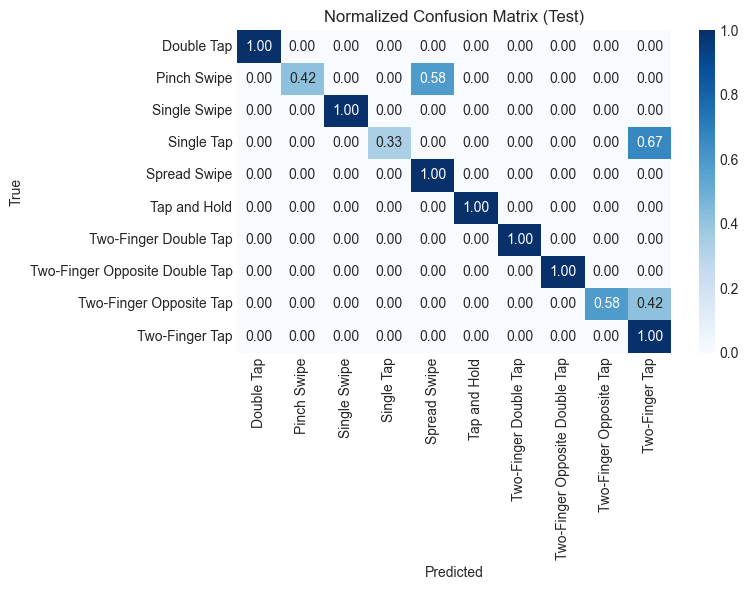

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_model.predict(X_test)

print("Test classification report:\n",
      classification_report(y_test, y_test_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

In [36]:
# Print which features are the most influencial for the best model if possible
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    importances = best_model.named_steps['clf'].feature_importances_
    feature_importance_pairs = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

    print("\nTop 50 Feature Importances:")
    for fname, importance in feature_importance_pairs[:50]:
        print(f"{fname}: {importance:.4f}")


Top 50 Feature Importances:
motor_angle_kurtosis: 0.0165
max_simultaneous_touches: 0.0162
finger_1_is_continuous_touch: 0.0139
finger_2_is_continuous_touch: 0.0138
finger_3_touch_reactivations: 0.0126
finger_3_touch_ends: 0.0117
total_active_touch_samples: 0.0104
finger_2_touch_reactivations: 0.0098
avg_active_touches: 0.0095
finger_3_touch_starts: 0.0094
finger_2_touch_ends: 0.0093
finger_1_continuous_touch_duration: 0.0093
active_moving_fingers: 0.0091
finger_3_is_continuous_touch: 0.0086
finger_2_max_time_between_reactivations: 0.0080
finger_2_mean_time_between_reactivations: 0.0079
finger_2_continuous_touch_duration: 0.0079
finger_distance_mean_first_third_1: 0.0078
finger_distance_min_1: 0.0078
finger_2_touch_starts: 0.0075
finger_2_min_time_between_reactivations: 0.0075
motor_angle_skewness: 0.0074
motor_angle_min: 0.0073
finger_1_min_touch_duration: 0.0073
finger_distance_min_2: 0.0073
finger_distance_mean_last_third_1: 0.0071
finger_2_total_touch_duration: 0.0069
finger_distan

## Test with Szenarios

In [37]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
WHERE is_gesture = 1 and marker_label != 'No Gesture'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,a0caf874-3fba-49a4-bd0e-36c370027f6b,002f4422-1f7b-4859-8f03-467e1f752000,335,2025-10-07 14:11:50,0,176.687363,0.395707,2063.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
1,b1971afb-c70b-45e2-970b-18512dd7beb4,002f4422-1f7b-4859-8f03-467e1f752000,336,2025-10-07 14:11:50,0,176.688904,0.394840,2067.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
2,7bbb27f4-3e45-467d-ba1e-a789024e1baf,002f4422-1f7b-4859-8f03-467e1f752000,337,2025-10-07 14:11:50,0,176.688126,0.394715,2065.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
3,86cfce39-cbc9-4917-86b6-fd2a80b1b3e3,002f4422-1f7b-4859-8f03-467e1f752000,338,2025-10-07 14:11:50,0,176.690048,0.394072,2079.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
4,c0cc105f-ec8c-4dd0-b8cd-4d1b61a9350a,002f4422-1f7b-4859-8f03-467e1f752000,339,2025-10-07 14:11:50,0,176.691193,0.393592,2081.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335


In [38]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [39]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [40]:
# Filter out all No Gesture markers
szenarien_df = szenarien_df[szenarien_df['marker_label'] != 'No Gesture']

In [41]:
nan_columns = szenarien_df.columns[szenarien_df.isna().any()].tolist()

In [42]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
dtype: int64

In [43]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
Tap and Hold                      2479
Spread Swipe                      1723
Single Swipe                      1450
Pinch Swipe                        838
Two-Finger Opposite Double Tap     629
Two-Finger Tap                     551
Two-Finger Double Tap              484
Double Tap                         367
Two-Finger Opposite Tap            315
Single Tap                          16
Name: count, dtype: int64


In [44]:
# Print count of unique session_tasks
print(f"Unique session_task_ids in Szenarien data: {szenarien_df['session_task_id'].nunique()}")

Unique session_task_ids in Szenarien data: 20


In [45]:
# Create windows for each group in the scenario data and extract their features, where one group is exactly one window
X_szenarien_sequences_raw = []
y_szenarien_labels = []
grouped = szenarien_df.groupby('group_id')

for group_id, group in grouped:
    sensor_data = group.sort_values('session_task_row_index')
    X_szenarien_sequences_raw.append(sensor_data[SENSOR_COLUMNS].to_numpy())
    # Use the most common marker_label in the group as the label
    most_common_label = sensor_data['marker_label'].mode()[0]
    y_szenarien_labels.append(most_common_label)

In [46]:
# Print the number of sequences and labels extracted
print(f"Extracted {len(X_szenarien_sequences_raw)} sequences from Szenarien data.")

# Print the label counts
print(pd.Series(y_szenarien_labels).value_counts())

Extracted 147 sequences from Szenarien data.
Two-Finger Tap                    28
Single Swipe                      25
Spread Swipe                      18
Two-Finger Opposite Double Tap    17
Two-Finger Double Tap             14
Tap and Hold                      13
Two-Finger Opposite Tap           13
Double Tap                        11
Pinch Swipe                        7
Single Tap                         1
Name: count, dtype: int64


In [47]:
y_pred = []
y_true = []

for seq, label in zip(X_szenarien_sequences_raw, y_szenarien_labels):
    features, _ = extract_features(seq, False)
    features = scaler.transform(features.reshape(1, -1))
    pred = best_model.predict(features)
    y_pred.append(pred[0])
    y_true.append(label)

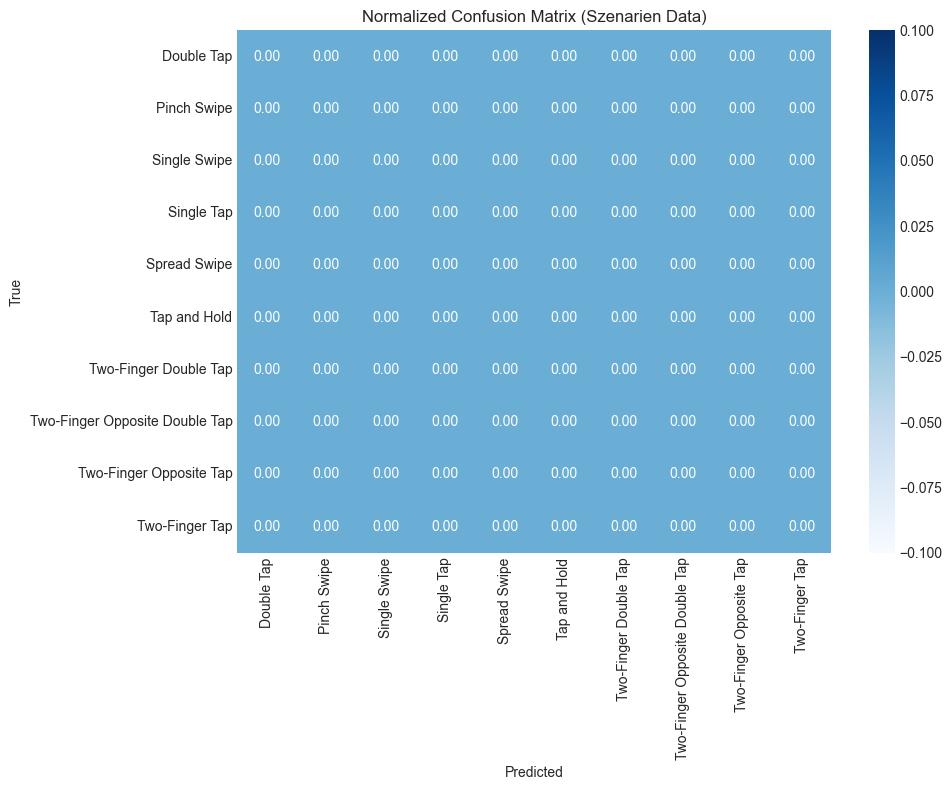

: 

In [54]:
# Draw confusion matrix for Szenarien predictions
cm = confusion_matrix(y_true, y_pred, labels=le.classes_)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Szenarien Data)")
plt.tight_layout()
plt.show()

## With sliding windows

In [49]:
# Create sliding windows
WINDOW_SIZE = 60
WINDOW_STRIDE = 10

def create_sliding_windows(data, window_size=WINDOW_SIZE, stride=WINDOW_STRIDE):
    windows = []
    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        window = data[start:end]
        windows.append(window)
    return windows

# For each session_task in the szenarien data, create sliding windows and extract features, where the label is the most common marker_label in the session_task
X_szenarien_sliding_windows_raw = []
y_szenarien_sliding_labels = []

grouped_session_tasks = szenarien_df.groupby('session_task_id')
for session_task_id, group in grouped_session_tasks:
    sensor_data = group.sort_values('session_task_row_index')
    windows = create_sliding_windows(sensor_data[SENSOR_COLUMNS].to_numpy())
    for window in windows:
        X_szenarien_sliding_windows_raw.append(window)
        # Use the most common marker_label in the session_task as the label
        most_common_label = sensor_data['marker_label'].mode()[0]
        y_szenarien_sliding_labels.append(most_common_label)
print(f"Created {len(X_szenarien_sliding_windows_raw)} sliding windows from Szenarien data.")

Created 776 sliding windows from Szenarien data.


In [50]:
# Print the label counts for sliding windows
print(pd.Series(y_szenarien_sliding_labels).value_counts())

Tap and Hold                      311
Spread Swipe                      244
Single Swipe                       93
Pinch Swipe                        62
Two-Finger Tap                     36
Two-Finger Opposite Double Tap     17
Two-Finger Double Tap              13
Name: count, dtype: int64


In [51]:
y_szenarien_sliding_pred = []
y_szenarien_sliding_true = []

for seq, label in zip(X_szenarien_sliding_windows_raw, y_szenarien_sliding_labels):
    features, _ = extract_features(seq, False)
    features = scaler.transform(features.reshape(1, -1))
    pred = best_model.predict(features)
    y_szenarien_sliding_pred.append(pred[0])
    y_szenarien_sliding_true.append(label)

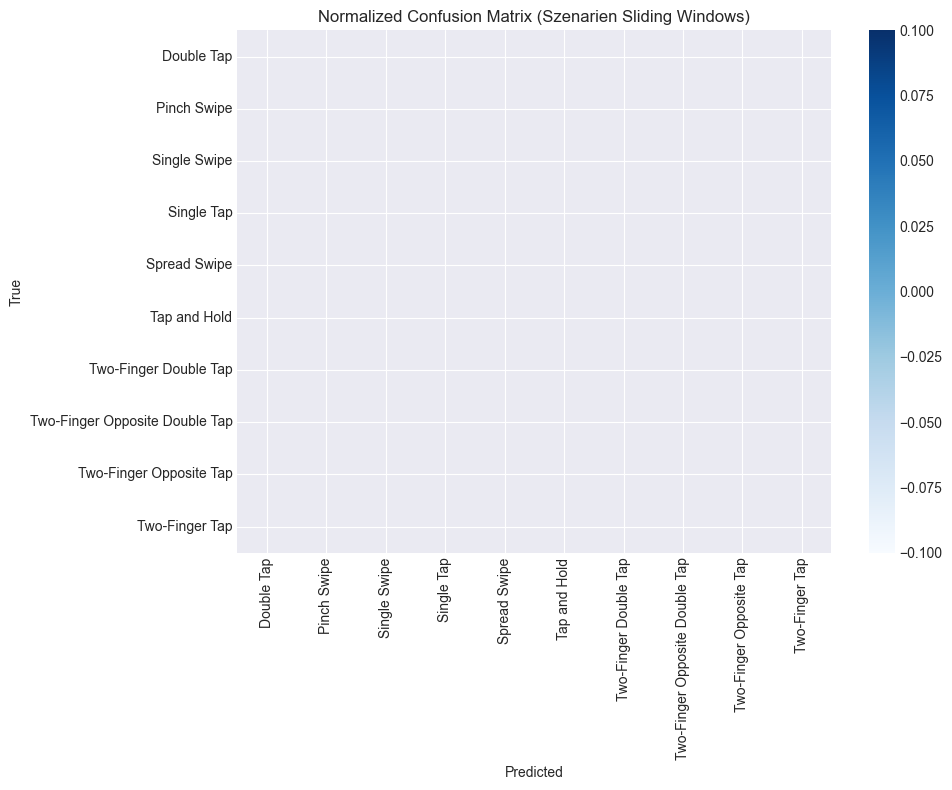

In [52]:
# Draw confusion matrix for Szenarien sliding window predictions
cm = confusion_matrix(y_szenarien_sliding_true, y_szenarien_sliding_pred, labels=le.classes_)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Szenarien Sliding Windows)")
plt.tight_layout()
plt.show()